In [13]:
# --- IMPORTS ---
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import rcParams

print("[INFO] Libraries loaded successfully")

[INFO] Libraries loaded successfully


In [14]:
from pathlib import Path
from matplotlib import rcParams

# --- CONFIGURATION & FONT SETUP ---
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

BASE_DIR = Path("../data/data/")  # current working directory

SPEI_FILE = BASE_DIR / "SPEI_1981_2024.nc"
MASK_FILE = BASE_DIR / "mask.nc"

OUT_DIR = BASE_DIR / "Ranking_SPEI"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("[INFO] Paths configured")
print("SPEI:", SPEI_FILE)
print("MASK:", MASK_FILE)
print("OUT:", OUT_DIR)

[INFO] Paths configured
SPEI: ..\data\data\SPEI_1981_2024.nc
MASK: ..\data\data\mask.nc
OUT: ..\data\data\Ranking_SPEI


In [15]:
# --- THRESHOLDS & TIME CONFIGURATION ---

# Thresholds (aligned with Liberato et al. 2021)
THR_MOD = -0.84   # Moderate/Severe
THR_EXT = -1.28   # Extreme
THR_VEX = -1.65   # Very Extreme


nombres_estacion = {1: 'Invierno (Feb)', 4: 'Primavera (May)', 7: 'Verano (Ago)', 10: 'Otoño (Nov)'}
año_inicio, año_fin = 1981, 2024

# Target months: Feb, May, Aug, Nov
meses_idx = [1, 4, 7, 10]

season_names = {
    1: 'Winter (Feb)',
    4: 'Spring (May)',
    7: 'Summer (Aug)',
    10: 'Autumn (Nov)'
}

start_year, end_year = 1981, 2024

print("[INFO] Temporal configuration ready")

[INFO] Temporal configuration ready


In [16]:
# --- DATA LOADING ---
print("[INFO] Loading SPEI dataset...")

ds = nc.Dataset(SPEI_FILE)

try:
    spei_raw = ds.variables["spei03"][:]
    print("[INFO] Variable 'spei03' found")
except KeyError:
    spei_raw = ds.variables["spei"][:]
    print("[WARNING] Using 'spei' instead of 'spei03'")

ds.close()

# Convert to float and clean values
spei_3d = np.ma.filled(spei_raw.astype(np.float64), np.nan)
spei_3d[(spei_3d < -10) | (spei_3d > 10)] = np.nan

print("[INFO] SPEI data loaded and cleaned")
print("Shape:", spei_3d.shape)

# --- MASK ---
print("[INFO] Loading mask...")

ds_m = nc.Dataset(MASK_FILE)
mask = np.array(ds_m.variables["mask"][:], dtype=float)
mask[mask == 0] = np.nan
ds_m.close()

print("[INFO] Mask loaded")
print("Mask shape:", mask.shape)

[INFO] Loading SPEI dataset...
[INFO] Variable 'spei03' found
[INFO] SPEI data loaded and cleaned
Shape: (528, 171, 611)
[INFO] Loading mask...
[INFO] Mask loaded
Mask shape: (171, 611)


In [17]:
# =============================================================================
# 2. CALCULATION OF AREA AND RANKING
# =============================================================================
print("Calculando Área y Ranking estacional para 3 umbrales...")
fechas = []
area_mod, rank_mod = [], []
area_ext, rank_ext = [], []
area_vex, rank_vex = [], []
registro_eventos = [] 

for year in range(año_inicio, año_fin + 1):
    for m in meses_idx:
        t = (year - año_inicio) * 12 + m
        if t >= spei_3d.shape[0]: 
            continue
        
        mapa_tierra = np.where(np.isnan(mask), np.nan, spei_3d[t, :, :])
        valid_pixels = ~np.isnan(mapa_tierra)
        N_total = np.sum(valid_pixels)
        
        if N_total == 0: continue
            
        # Umbral 1 (-0.84)
        mask_mod = valid_pixels & (mapa_tierra <= THR_MOD)
        A_mod = (np.sum(mask_mod) / N_total) * 100
        I_mod = np.abs(np.mean(mapa_tierra[mask_mod])) if np.sum(mask_mod) > 0 else 0
        R_mod = I_mod * A_mod
        
        # Umbral 2 (-1.28)
        mask_ext = valid_pixels & (mapa_tierra <= THR_EXT)
        A_ext = (np.sum(mask_ext) / N_total) * 100
        I_ext = np.abs(np.mean(mapa_tierra[mask_ext])) if np.sum(mask_ext) > 0 else 0
        R_ext = I_ext * A_ext

        # Umbral 3 (-1.65)
        mask_vex = valid_pixels & (mapa_tierra <= THR_VEX)
        A_vex = (np.sum(mask_vex) / N_total) * 100
        I_vex = np.abs(np.mean(mapa_tierra[mask_vex])) if np.sum(mask_vex) > 0 else 0
        R_vex = I_vex * A_vex
        
        frac_year = year + (m / 12.0) 
        fechas.append(frac_year)
        
        area_mod.append(A_mod); rank_mod.append(R_mod)
        area_ext.append(A_ext); rank_ext.append(R_ext)
        area_vex.append(A_vex); rank_vex.append(R_vex)
        
        registro_eventos.append({
            'año': year, 'estacion': nombres_estacion[m], 
            'R_mod': R_mod, 'A_mod': A_mod, 
            'R_ext': R_ext, 'A_ext': A_ext,
            'R_vex': R_vex, 'A_vex': A_vex
        })


Calculando Área y Ranking estacional para 3 umbrales...


Generando figuras de alta resolución con paleta jerárquica...

Proceso finalizado. Gráficas actualizadas en ..\data\data\Ranking_SPEI


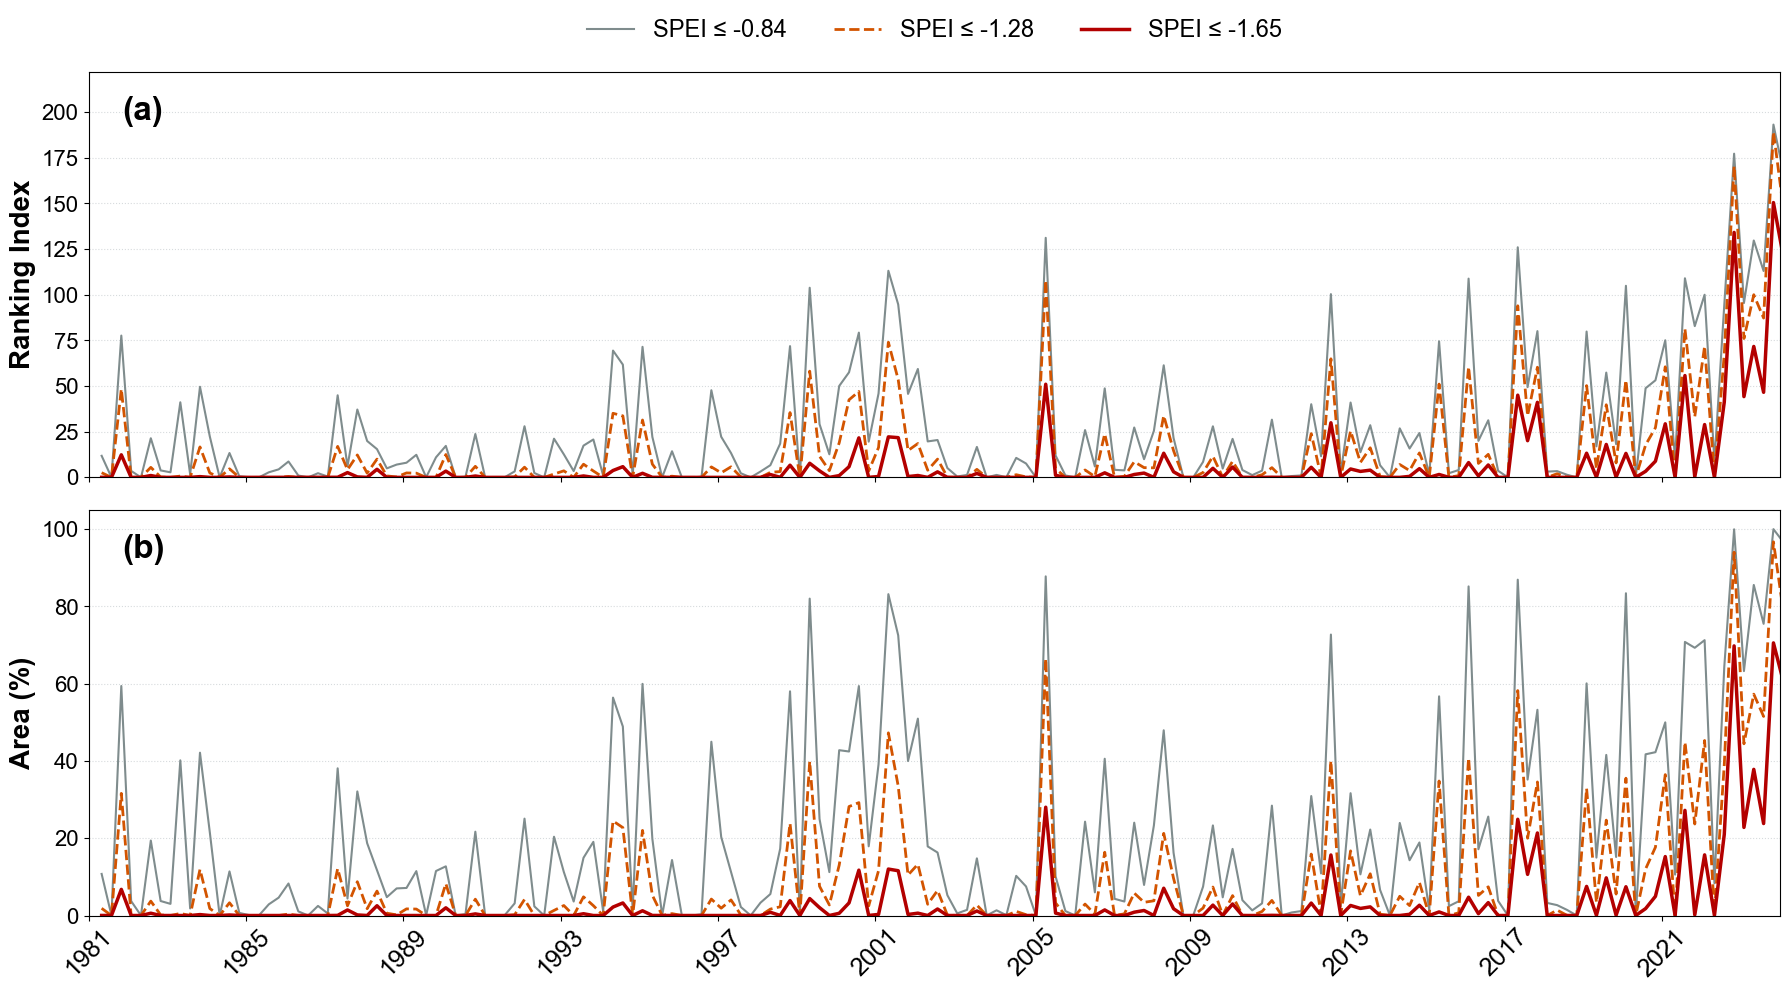

In [18]:
# =============================================================================
# 3. VISUALISATION (EDITORIAL QUALITY)
# =============================================================================
# =============================================================================
# 3. VISUALISATION (EDITORIAL QUALITY - REFINED PALETTE)
# =============================================================================
print("Generando figuras de alta resolución con paleta jerárquica...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Configuraciones de estilo: jerarquía visual de severidad
c_mod, ls_mod, lw_mod = '#7f8c8d', '-', 1.5   # Gris pizarra
c_ext, ls_ext, lw_ext = '#d35400', '--', 2.0  # Naranja tostado
c_vex, ls_vex, lw_vex = '#b30000', '-', 2.5   # Rojo intenso

# --- Panel 1: Ranking Index ---
ax1.plot(fechas, rank_mod, color=c_mod, linestyle=ls_mod, linewidth=lw_mod, label=f'SPEI ≤ {THR_MOD}')
ax1.plot(fechas, rank_ext, color=c_ext, linestyle=ls_ext, linewidth=lw_ext, label=f'SPEI ≤ {THR_EXT}')
ax1.plot(fechas, rank_vex, color=c_vex, linestyle=ls_vex, linewidth=lw_vex, label=f'SPEI ≤ {THR_VEX}')

ax1.set_ylabel('Ranking Index', fontsize=20, fontweight='bold')
ax1.tick_params(axis='y', labelsize=16)
ax1.grid(axis='y', linestyle=':', alpha=0.6, color='#bdc3c7') 
ax1.set_ylim(bottom=0)
ax1.set_ylim(top=max(rank_mod) * 1.15) 

# Leyenda en la parte SUPERIOR, fuera del gráfico
ax1.legend(fontsize=17, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

# Etiqueta (a) a la izquierda
ax1.text(0.02, 0.94, '(a)', transform=ax1.transAxes, fontsize=24, fontweight='bold', va='top', ha='left')

# --- Panel 2: Area ---
ax2.plot(fechas, area_mod, color=c_mod, linestyle=ls_mod, linewidth=lw_mod)
ax2.plot(fechas, area_ext, color=c_ext, linestyle=ls_ext, linewidth=lw_ext)
ax2.plot(fechas, area_vex, color=c_vex, linestyle=ls_vex, linewidth=lw_vex)

ax2.set_ylabel('Area (%)', fontsize=20, fontweight='bold')
ax2.tick_params(axis='y', labelsize=16)
ax2.tick_params(axis='x', labelsize=18, rotation=45)
ax2.grid(axis='y', linestyle=':', alpha=0.6, color='#bdc3c7')
ax2.set_ylim(bottom=0, top=105)

# Etiqueta (b) a la izquierda
ax2.text(0.02, 0.94, '(b)', transform=ax2.transAxes, fontsize=24, fontweight='bold', va='top', ha='left')

# Formato del Eje X
x_ticks = np.arange(año_inicio, año_fin + 1, 4)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(int(x)) for x in x_ticks])
ax2.set_xlim(año_inicio, año_fin)

plt.tight_layout()
plt.subplots_adjust(hspace=0.08)

# Guardar
plt.savefig(OUT_DIR / "Seasonal_Drought_Ranking_SPEI03_Final.png", dpi=300, bbox_inches='tight')
plt.savefig(OUT_DIR / "Seasonal_Drought_Ranking_SPEI03_Final.pdf", dpi=300, bbox_inches='tight')

print(f"\nProceso finalizado. Gráficas actualizadas en {OUT_DIR}")
plt.show()